In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def moving_average(a, n=10):
    if len(a) == 0:
        return []
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [4]:
json_paths = [
    # "weights_dir_2_cnn_reinforce/learning_data.json",
    # "weights_dir_2_cnn_reinforce_baseline/learning_data.json",
    "weights_dir_cnn_trpo/learning_data.json",
]

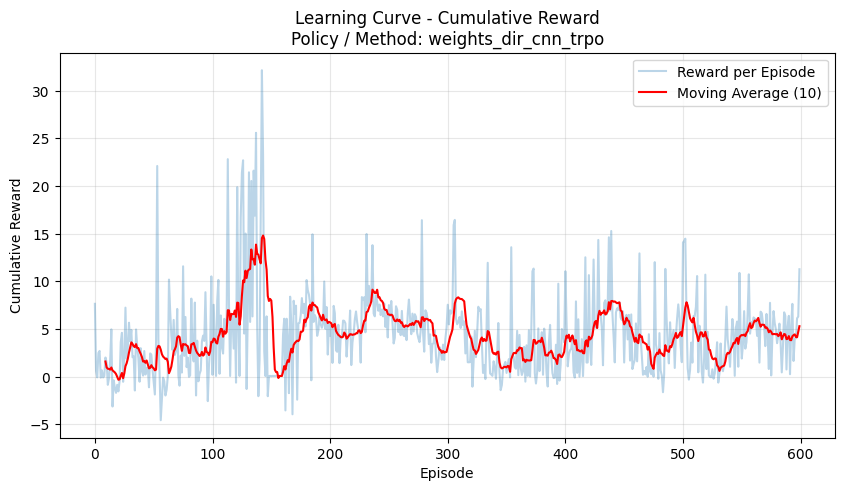

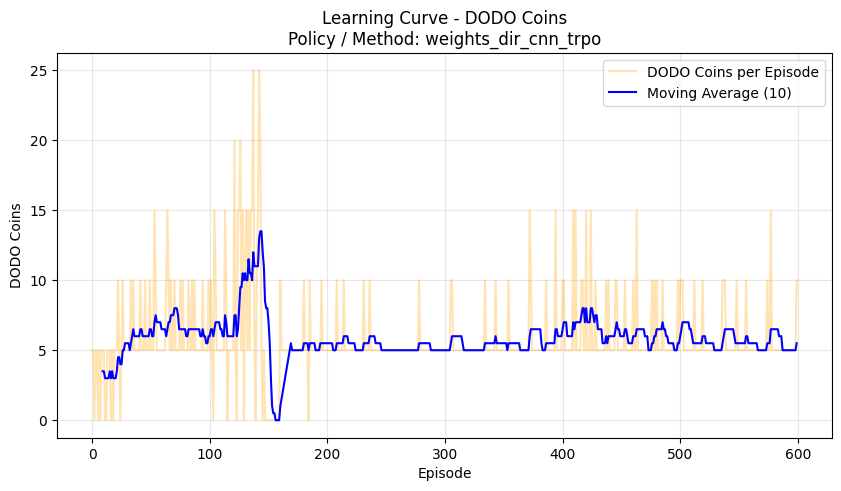

--------------------------------------------------------------------------------


In [6]:
for path in json_paths:
    if not os.path.exists(path):
        print(f"\n[!] Файл не найден: {path}")
        pass
    else:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        episode_rewards = data.get("rewards", [])[:600]
        episode_coins = data.get("coins", [])[:600]
        
        parent_dir = os.path.basename(os.path.dirname(path))
        title_suffix = f"\nPolicy / Method: {parent_dir}"
        
        if len(episode_rewards) > 0:
            plt.figure(figsize=(10, 5))
            plt.plot(episode_rewards, label="Reward per Episode", alpha=0.3)
            if len(episode_rewards) >= 10:
                ma_rewards = moving_average(episode_rewards, n=10)
                plt.plot(range(9, len(episode_rewards)), ma_rewards, label="Moving Average (10)", color='red')
            plt.xlabel("Episode")
            plt.ylabel("Cumulative Reward")
            plt.title(f"Learning Curve - Cumulative Reward{title_suffix}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
            
        if len(episode_coins) > 0:
            plt.figure(figsize=(10, 5))
            plt.plot(episode_coins, label="DODO Coins per Episode", alpha=0.3, color='orange')
            if len(episode_coins) >= 10:
                ma_coins = moving_average(episode_coins, n=10)
                plt.plot(range(9, len(episode_coins)), ma_coins, label="Moving Average (10)", color='blue')
            plt.xlabel("Episode")
            plt.ylabel("DODO Coins")
            plt.title(f"Learning Curve - DODO Coins{title_suffix}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
            
        print("-" * 80)
